In [3]:
# Cargar la extensión mágica de SQL
%load_ext sql

In [9]:
%config SqlMagic.style = '_DEPRECATED_DEFAULT'

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/marco-canas/fundamentos_de_programacion/blob/main/clases/0_formato_clases_fundamentos_programacion/4_formato_clase_funda_programacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/marco-canas/fundamentos_de_programacion/blob/main/clases/0_formato_clases_fundamentos_programacion/4_formato_clase_funda_programacion.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

In [ ]:
import qrcode
from IPython.display import display
from PIL import Image

def generar_qr(url, version=1, box_size=5, border=4, fill_color="black", back_color="white"):
    qr = qrcode.QRCode(
        version=version,
        error_correction=qrcode.constants.ERROR_CORRECT_L,
        box_size=box_size,
        border=border,
    )
    
    # Añadir la URL al QR
    qr.add_data(url)
    qr.make(fit=True)
    
    # Crear la imagen del QR
    img = qr.make_image(fill_color=fill_color, back_color=back_color)
     
    return img



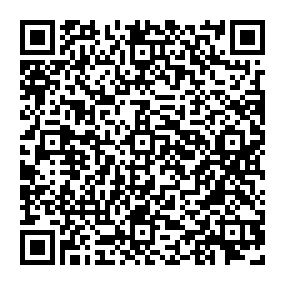

In [2]:
url = "https://colab.research.google.com/github/marco-canas/fundamentos_de_programacion/blob/main/clases/0_formato_clases_fundamentos_programacion/4_formato_clase_funda_programacion.ipynb"
generar_qr(url) 

### [Video de apoyo a la lectura interactiva y experimental de este cuaderno]()

### [Vínculo al programa del curso de Fundamentos de Programación:](https://github.com/marco-canas/fundamentos_de_programacion/blob/main/programa/Programa_Fundamentos_Programacion.md)



## Código del curso: 314029

Un reconocimiento a mis estudiantes que han construido conmigo este saber pedagógico:

<img src = 'https://github.com/marco-canas/algebra_y_trigonometria/blob/main/7_images/5_clase_3_2025-08-12_hora_11_04.jpg?raw=true' width = 400> 



In [2]:
import pandas as pd
import numpy as np

# Cargar la lista de estudiantes desde el archivo CSV
path = 'C:/Users/marco/Documentos/docencia/groups_list/fundamentos_programacion.xlsx'
df = pd.read_excel(path)
df.index = np.arange(1, len(df) + 1)  # Cambiar el índice para que empiece en 1
df.head(7)


,Cédula,Nombre,Email,p3
1,1038648096,ACEVEDO BELEÑO SANTIAGO,sacevedo.beleno@udea.edu.co,NaN
2,1038113597,CORREA RESTREPO NICOLAS,nicolas.crestrepo@udea.edu.co,2.5
3,1038648760,MARIN VILLARREAL PABLO ALEJANDRO,pablo.marin1@udea.edu.co,NaN
4,1038647828,NIEBLES BARRERA ALEXANDER ISAAC,alexander.niebles@udea.edu.co,NaN
5,1038092717,RIVERA GUZMAN CRISTIAN,cristian.rivera2@udea.edu.co,NaN
6,1066600819,TIRADO CHAVARRIA WILFRAN DE JESUS,wilfran.tirado@udea.edu.co,NaN


## Diseño de clase



**Tema:** Introducción al lenguaje SQL para ciencia de datos


**Ubicación en el curso:** Clase de cierre del curso *Fundamentos de programación con Python y SQL para ciencia de datos*



## 1. Propósito formativo

Introducir a los estudiantes de matemáticas en el lenguaje SQL como herramienta formal para consultar, estructurar y analizar datos, articulando su uso con Python en contextos de ciencia de datos y modelación matemática.




## 2. Resultados de aprendizaje

Al finalizar la clase, el estudiante será capaz de:

1. Comprender el rol de SQL en el ecosistema de ciencia de datos.


2. Identificar la estructura lógica de una base de datos relacional.


3. Formular consultas básicas en SQL.
4. Relacionar SQL con Python para análisis matemático y estadístico.
5. Interpretar consultas como operaciones sobre conjuntos y relaciones.



## 3. Articulación con la formación matemática

Esta clase conecta SQL con:

* lógica matemática (proposiciones, condiciones)
* teoría de conjuntos (selección, unión, intersección)
* relaciones y funciones
* modelación de datos
* estructuras discretas



Idea central:

> SQL puede interpretarse como un lenguaje formal para operar sobre conjuntos de datos.




## 4. Saberes a desarrollar



## Conceptuales

* Base de datos relacional
* Tabla como relación matemática
* Clave primaria
* Consulta (query)
* Álgebra relacional básica



# Procedimentales

* Escribir consultas SQL
* Filtrar datos
* Agrupar información
* Integrar SQL con Python



### Actitudinales

* Pensamiento estructurado
* Rigor en la formulación de consultas
* Interpretación matemática de datos




# 5. Contenidos

## 5.1 Ecosistema de datos

* Python y SQL en ciencia de datos
* Flujo:
  datos → base de datos → consulta → análisis → modelo



## 5.2 Conceptos fundamentales

* Base de datos
* Tabla
* Registro
* Campo
* Clave primaria



## 5.3 Sintaxis básica SQL

* SELECT
* FROM
* WHERE
* ORDER BY
* GROUP BY
* COUNT, AVG, SUM



## 5.4 SQL + Python

* lectura de bases de datos
* análisis posterior con pandas




## 6. Secuencia didáctica

### 6.1 Apertura (30 min)

Pregunta detonante:

> ¿Cómo se organizan matemáticamente grandes volúmenes de datos para poder analizarlos?

Discusión:

* datos como estructuras
* relaciones entre variables
* necesidad de lenguajes formales

Analogía:

Tabla ↔ relación matemática

---


Basándome en los contenidos del cuaderno Jupyter que proporcionaste, las consultas y las explicaciones de la clase están diseñadas en torno a un conjunto de datos específico de **ventas, productos y empleados** que incluye campos como `id`, `nombre`, `monto` (en transacciones) y descripciones textuales. Además, utiliza la extensión `%load_ext sql` que opera de forma predeterminada con una base de datos relacional (generalmente SQLite en memoria o un archivo local).



A continuación, te presento el script de Python utilizando `sqlite3` y `pandas` para generar de manera automática un archivo de base de datos relacional (`clase_sql.db`) con datos artificiales coherentes con la temática y los ejemplos implícitos en el formato del curso.

## Script en Python para crear los datos artificiales


In [10]:
import sqlite3
import pandas as pd
import random
from datetime import datetime, timedelta

def crear_base_datos_clase(nombre_bd="clase_sql.db"):
    # Conectar a la base de datos (se creará el archivo si no existe)
    conexion = sqlite3.connect(nombre_bd)
    cursor = conexion.cursor()

    # 1. Eliminar tablas si ya existen para permitir re-ejecución limpia
    cursor.execute("DROP TABLE IF EXISTS ventas;")
    cursor.execute("DROP TABLE IF EXISTS empleados;")
    cursor.execute("DROP TABLE IF EXISTS productos;")

    # 2. Crear Tabla de PRODUCTOS
    cursor.execute("""
    CREATE TABLE productos (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        nombre TEXT NOT NULL,
        categoria TEXT,
        precio REAL NOT NULL
    );
    """)

    # 3. Crear Tabla de EMPLEADOS
    cursor.execute("""
    CREATE TABLE empleados (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        nombre TEXT NOT NULL,
        cargo TEXT,
        fecha_ingreso TEXT,
        salario REAL
    );
    """)

    # 4. Crear Tabla de VENTAS (Transacciones masivas para ejercicios agregados)
    cursor.execute("""
    CREATE TABLE ventas (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        producto_id INTEGER,
        empleado_id INTEGER,
        monto REAL NOT NULL,
        fecha TEXT,
        FOREIGN KEY (producto_id) REFERENCES productos(id),
        FOREIGN KEY (empleado_id) REFERENCES empleados(id)
    );
    """)

    # --- INSERTAR DATOS ARTIFICIALES ---

    # Datos para Productos
    productos_datos = [
        ("Laptop Core i7", "Electrónica", 1200.00),
        ("Smartphone Pro", "Electrónica", 850.00),
        ("Monitor 4K 27''", "Accesorios", 350.00),
        ("Teclado Mecánico", "Accesorios", 90.00),
        ("Mouse Ergonómico", "Accesorios", 45.00),
        ("Escritorio Ajustable", "Mobiliario", 450.00),
        ("Silla Ergonómica", "Mobiliario", 280.00),
        ("Auriculares Noise Cancelling", "Audio", 150.00)
    ]
    cursor.executemany("INSERT INTO productos (nombre, categoria, precio) VALUES (?, ?, ?);", productos_datos)

    # Datos para Empleados
    empleados_datos = [
        ("Marco Cañas", "Profesor / Director", "2020-01-15", 3500.00),
        ("Ana Martínez", "Líder de Ventas", "2021-03-22", 2800.00),
        ("Carlos Gómez", "Asesor Comercial", "2022-06-10", 1800.00),
        ("Elena Rodríguez", "Asistente de Ventas", "2023-01-05", 1500.00),
        ("Luis Beltrán", "Asesor Comercial", "2022-11-18", 1800.00)
    ]
    cursor.executemany("INSERT INTO empleados (nombre, cargo, fecha_ingreso, salario) VALUES (?, ?, ?, ?);", empleados_datos)

    # Generar Datos de Ventas de forma aleatoria (Para simular ejercicios reales de SQL)
    random.seed(42) # Mantener consistencia en los datos generados
    ventas_datos = []
    fecha_base = datetime(2025, 1, 1)

    for _ in range(100): # Crear 100 transacciones artificiales
        prod_id = random.randint(1, len(productos_datos))
        emp_id = random.randint(1, len(empleados_datos))
        
        # El precio base del producto seleccionado
        precio_base = productos_datos[prod_id - 1][2]
        # El monto puede variar levemente por supuestos descuentos aplicados
        monto = round(precio_base * random.uniform(0.9, 1.1), 2)
        
        # Fecha aleatoria en los últimos meses
        dias_aleatorios = random.randint(0, 120)
        fecha_venta = (fecha_base + timedelta(days=dias_aleatorios)).strftime("%Y-%m-%d")
        
        ventas_datos.append((prod_id, emp_id, monto, fecha_venta))

    cursor.executemany("INSERT INTO ventas (producto_id, empleado_id, monto, fecha) VALUES (?, ?, ?, ?);", ventas_datos)

    # Guardar cambios y cerrar conexión
    conexion.commit()
    conexion.close()
    print(f"¡Base de datos '{nombre_bd}' creada con éxito junto con datos artificiales para la clase!")

if __name__ == "__main__":
    crear_base_datos_clase()


¡Base de datos 'clase_sql.db' creada con éxito junto con datos artificiales para la clase!



# Cómo usar este script en tu cuaderno Jupyter:

Para integrar estos datos perfectamente en tu flujo de trabajo con la extensión `%load_ext sql` presente en tu archivo, añade y ejecuta las siguientes celdas de código consecutivas:

**Celda 1: Crear los datos (Ejecución del Script)**



In [11]:
# Ejecutamos la función de generación que definimos arriba
crear_base_datos_clase("clase_sql.db")


¡Base de datos 'clase_sql.db' creada con éxito junto con datos artificiales para la clase!



**Celda 2: Conexión mediante SQL Magic**


In [12]:
%load_ext sql
%sql sqlite:///clase_sql.db


The sql extension is already loaded. To reload it, use:
  %reload_ext sql



**Celda 3: Probar los datos con una consulta**


In [13]:
%%sql
SELECT e.nombre AS Empleado, SUM(v.monto) AS Total_Vendido
FROM ventas v
JOIN empleados e ON v.empleado_id = e.id
GROUP BY e.nombre
ORDER BY Total_Vendido DESC;


 * sqlite:///clase_sql.db
Done.


Empleado,Total_Vendido
Ana Martínez,12807.19
Marco Cañas,12370.58
Luis Beltrán,10777.0
Elena Rodríguez,5570.62
Carlos Gómez,4257.72



Este esquema de datos provee el escenario perfecto para enseñar comandos fundamentales de SQL (`SELECT`, `WHERE`, `GROUP BY`, `ORDER BY`, `SUM`, `AVG`) y operaciones avanzadas como uniones relacionales (`JOIN`) que son los tópicos centrales de un módulo introductorio.


### 6.2 Desarrollo (2 horas)

## Bloque 1: Modelo relacional desde la matemática

Ejemplo:

Tabla estudiantes:

| id | nombre | programa | promedio |
| -- | ------ | -------- | -------- |

Interpretación:

* conjunto de individuos
* atributos como funciones definidas sobre el conjunto



# Bloque 2: Primeras consultas SQL

Base: ventas_empresa

## Consulta 1: selección de datos


In [15]:
%sql SELECT * FROM ventas;


 * sqlite:///clase_sql.db
Done.


id,producto_id,empleado_id,monto,fecha
1,2,1,891.06,2025-02-01
2,4,2,94.26,2025-03-28
3,2,5,836.73,2025-01-04
4,2,2,804.55,2025-03-19
5,1,5,1127.72,2025-03-25
6,7,2,277.16,2025-02-05
7,1,2,1247.55,2025-02-13
8,5,2,42.44,2025-04-08
9,6,1,413.35,2025-01-13
10,6,3,459.34,2025-04-14


Interpretación matemática:

* recuperar el conjunto completo




## Consulta 2: proyección


In [18]:
%sql SELECT producto_id, monto FROM ventas;


 * sqlite:///clase_sql.db
Done.


producto_id,monto
2,891.06
4,94.26
2,836.73
2,804.55
1,1127.72
7,277.16
1,1247.55
5,42.44
6,413.35
6,459.34


* selección de atributos
* proyección en álgebra relacional



### Consulta 3: filtrado


In [21]:
%sql SELECT p.nombre AS producto, v.monto AS precio FROM ventas v JOIN productos p ON v.producto_id = p.id;

 * sqlite:///clase_sql.db
Done.


producto,precio
Smartphone Pro,891.06
Teclado Mecánico,94.26
Smartphone Pro,836.73
Smartphone Pro,804.55
Laptop Core i7,1127.72
Silla Ergonómica,277.16
Laptop Core i7,1247.55
Mouse Ergonómico,42.44
Escritorio Ajustable,413.35
Escritorio Ajustable,459.34


In [25]:
%%sql
SELECT * FROM ventas
WHERE monto > 500;

 * sqlite:///clase_sql.db
Done.


id,producto_id,empleado_id,monto,fecha
1,2,1,891.06,2025-02-01
3,2,5,836.73,2025-01-04
4,2,2,804.55,2025-03-19
5,1,5,1127.72,2025-03-25
7,1,2,1247.55,2025-02-13
11,1,4,1208.69,2025-04-29
14,1,2,1265.54,2025-01-11
20,1,2,1277.23,2025-04-14
27,2,2,871.67,2025-04-12
30,1,1,1243.61,2025-03-10


* subconjunto definido por condición lógica

---



# Consulta 4: ordenamiento



In [28]:
%%sql
SELECT * FROM ventas
ORDER BY monto DESC;


 * sqlite:///clase_sql.db
Done.


id,producto_id,empleado_id,monto,fecha
59,1,1,1302.33,2025-04-19
20,1,2,1277.23,2025-04-14
14,1,2,1265.54,2025-01-11
65,1,5,1256.58,2025-01-08
7,1,2,1247.55,2025-02-13
30,1,1,1243.61,2025-03-10
85,1,1,1232.23,2025-04-17
46,1,5,1212.94,2025-03-17
11,1,4,1208.69,2025-04-29
36,1,5,1157.8,2025-01-03


* relación ordenada




# Bloque 3: Agregación y análisis

## Conteo


In [29]:
%sql SELECT COUNT(*) FROM ventas;


 * sqlite:///clase_sql.db
Done.


COUNT(*)
100


## Promedio

```sql


In [30]:
%sql SELECT AVG(monto) FROM ventas;


 * sqlite:///clase_sql.db
Done.


AVG(monto)
457.8311



### Suma

```sql


In [32]:
%sql SELECT SUM(monto) FROM ventas;


 * sqlite:///clase_sql.db
Done.


SUM(monto)
45783.11



Interpretación:

* operadores funcionales sobre conjuntos de datos

---


In [2]:
SELECT SUM(ingresos) FROM ventas;

SyntaxError: invalid syntax (1281141653.py, line 1)


### Agrupación

```sql
SELECT producto, SUM(ingresos)
FROM ventas
GROUP BY producto;
```

Relación con:

* partición de conjuntos
* funciones definidas por clases

---

## Bloque 4: SQL + Python

Ejemplo conceptual:

```python


In [34]:
import pandas as pd
import sqlite3

# 1. Conectar a la base de datos correcta (donde se crearon los datos artificiales)
conexion = sqlite3.connect("clase_sql.db")

# 2. Consulta corregida con las columnas reales y un JOIN para traer el nombre del producto
consulta = """
SELECT p.nombre AS producto, SUM(v.monto) AS total_ingresos
FROM ventas v
JOIN productos p ON v.producto_id = p.id
GROUP BY p.nombre
ORDER BY total_ingresos DESC;
"""

# 3. Cargar el resultado directamente en un DataFrame de Pandas
df = pd.read_sql(consulta, conexion)

# 4. Cerrar la conexión (buena práctica en Python)
conexion.close()

# 5. Visualizar el DataFrame en VS Code
df

,producto,total_ingresos
0,Laptop Core i7,16874.80
1,Smartphone Pro,13732.82
2,Escritorio Ajustable,6215.93
3,Silla Ergonómica,2770.62
4,Monitor 4K 27'',2338.62
5,Auriculares Noise Cancelling,2069.31
6,Teclado Mecánico,1340.67
7,Mouse Ergonómico,440.34


Idea:

* SQL organiza
* Python modela y analiza

---



### 6.3 Actividad central (45 min)

Base: datos académicos

Tabla:

* estudiantes
* cursos
* calificaciones

Problemas:

1. Obtener promedio general.
2. Estudiantes con promedio mayor a 4.
3. Curso con más inscritos.
4. Promedio por programa.
5. Número de estudiantes por semestre.

---



### 6.4 Cierre (30 min)

Discusión:

* SQL como lenguaje formal
* relación con lógica matemática
* relación con modelación

Idea final:

> Python permite modelar, SQL permite estructurar el mundo de datos sobre el cual modelamos.

---

## 7. Evaluación

### Formativa

* construcción de consultas
* interpretación matemática

### Sumativa (reto final)

Problema:

Una base de datos de ventas contiene:

* producto
* fecha
* cantidad
* precio

Solicitar:

1. ventas totales
2. producto más vendido
3. promedio mensual
4. ventas por categoría

---



## 8. Recursos

* Google Colab
* SQLite
* VS Code
* Base de datos de ejemplo
* Proyector

---



## 9. Tarea final del curso

Mini–proyecto integrador:

Flujo completo:

1. Base de datos SQL.
2. Consultas estructurales.
3. Lectura con Python.
4. Análisis estadístico.
5. Visualización.
6. Conclusión matemática.

---



## 10. Proyección académica

Esta clase abre paso a:

* bases de datos para modelación matemática
* minería de datos
* series de tiempo
* machine learning
* investigación cuantitativa

---



## 11. Idea de cierre del curso

Para un matemático:

* Python = lenguaje para modelar
* SQL = lenguaje para estructurar datos
* Machine learning = lenguaje para aprender patrones

Triada formativa:

matemática + programación + datos = ciencia de datos.

---



Si quieres, puedo prepararte ahora para cerrar el curso completamente:

1. Notebook en Colab: SQL + Python aplicado a un problema real.
2. Base de datos académica en SQLite lista para usar.
3. Proyecto final evaluable para matemáticos.
4. Rúbrica de evaluación del cierre del curso.


## Referentes 

[Libro guía Fundamentos de programación: Data Analysis with Python: Introducing NumPy, Pandas, Matplotlib, and Essential Elements of Python Programming (English Edition) [Kindle Edition]](https://read.amazon.com/?_encoding=UTF8&asin=B0BBB56L4X&consumptionLimitReached=false&deviceAccountIds=A1032123ZASLV79K77QP&hasMultimedia=false&requiredCapabilities=EBOK_PURCHASE_ALLOWED&ref=sr_rn_kfw) Este vínculo lo debo abrir con Chrome

### [Evaluamos al profesor Marco Cañas Aquí](https://forms.office.com/Pages/ResponsePage.aspx?id=IefhmYRxjkmK_7KtTlPBwkanXIs1i1FEujpsZgO6dXpUREJPV1kxUk1JV1ozTFJIQVNIQjY5WEY3US4u)

### Continue su aprendizaje en la siguiente clase a través del siguiente [vínculo]()